In [1]:
%run Packages_and_Functions.ipynb

from numpy.linalg import eigh, matrix_rank,pinv, norm, eig
import timeit

In [4]:
# size = 4
# count = 0
# for i in range(1000):
#     T = np.random.uniform(size = size)
#     for i in range(size):
#         if sum([T[(i + j) % size] for j in range(size-1)]) < T[(i+ size-1)%size]:
#             count+=1
# count

In [7]:
L = [-5.583646004488967, -5.576991624290983, -5.502692512794402, -5.4985869616452625, -5.427484325987718, -5.414170039884153, -5.370329294941801, -5.356463358619132, -5.334271155369757, -5.313975965848481, -5.27977929007692, -5.2664779788183615, -5.219438285922813, -5.212532019459774, -5.183702395336537, -5.166252112824527, -5.144482391499723, -5.115830639174769, -5.10777394042708, -5.084043016853732, -5.075074933209285, -5.049243504918556, -5.03672768491111, -5.012827673419304, -4.994889882778615, -4.975274742986839, -4.9579559755963505, -4.934293927641065, -4.921745404307032, -4.898768304396045, -4.8927917301642605, -4.848565602009664, -4.81857694470515, -4.797229051008463, -4.786141138697836, -4.76707318852257, -4.755975727880559, -4.745083064418278, -4.7332068763841, -4.717261822929386, -4.701040590881735, -4.687938788267237, -4.679593512511428, -4.671122425233021, -4.634472533647358, -4.628753150230645, -4.6185190331211015, -4.593619824209675, -4.588142635671941, -4.570954905217825, -4.565005526798435, -4.541261416410984, -4.526858568605329, -4.494045352209854, -4.483044158948941, -4.482292014336707, -4.476350488688963, -4.454597664536545, -4.450833789511469, -4.425055449342345, -4.408298187927734, -4.401302869261242, -4.387689139615221, -4.3733498311011445, -4.363299666695186, -4.346796315598716, -4.318815155528426, -4.3009486129005285, -4.29688917154137, -4.288387104511511, -4.27559608241436, -4.2530802096874325, -4.2443205342297485, -4.2351466181490665, -4.216637183426059, -4.201136173911047, -4.185529166261139, -4.1771836543639775, -4.171419939330855, -4.143507002037049, -4.132841186507742, -4.106528436556996, -4.096948446176919, -4.080810072983994, -4.071207721980759, -4.051156653801522, -4.038799584606469, -4.034681542926931, -4.014458206210703, -4.011287672154964, -4.005901118106149, -3.9869798293842926, -3.986047156737542, -3.955174044919528, -3.9487880626524516, -3.9386799706404494, -3.9243000507111123, -3.9185173330432246, -3.899018492927519, -3.8864669262204155, -3.8795286632545194, -3.8750955190420973, -3.851507094053349, -3.8364833893601533, -3.8254197109243613, -3.8177011036262405, -3.8058183183373986, -3.7933723701642172, -3.7874430149910943, -3.7736086986279913, -3.767861633850633, -3.7655474196127727, -3.745148962705602, -3.7323705570631054, -3.724736113851705, -3.7146802913318684, -3.6923359890339373, -3.6867147404330574, -3.6705907214074163, -3.661200244544661, -3.6549269376999023, -3.6492017801817616, -3.6402119250296705, -3.619474826812513, -3.6059112049718367, -3.590377644466744, -3.583702259178878, -3.5770088538516047, -3.557765523627314, -3.5497797235240593, -3.541675240368141, -3.529981395984808, -3.520669060222005, -3.507279261147848, -3.497215190893911, -3.4881909136717084, -3.4708393727227307, -3.4543210241340088, -3.4437052451044092, -3.4389914953825587, -3.434674878348093, -3.4315689185388685, -3.396726769587521, -3.3826322720258517, -3.3815265089124766, -3.3710469397101193, -3.3563696217337524, -3.3493044412179973, -3.3465378335194957, -3.3362911852389967, -3.3233413937431715, -3.3131471146316063, -3.2998912592325462, -3.2981339700835006, -3.281634905922221, -3.271955816393991, -3.2619571536006156, -3.257408199711911, -3.240013887129087, -3.225867071947021, -3.20657659047452, -3.203001263548579, -3.1971894978660593, -3.1793123429353054, -3.1697062130390163, -3.166557734768424, -3.161267154231383, -3.1523471072730533, -3.1296670583816892, -3.127951309320072, -3.1123005782182815, -3.0980235985089033, -3.090696860623771, -3.079668169638758, -3.0774832770936307, -3.063950846079875, -3.0578498328584027, -3.045787289114089, -3.0385601101691275, -3.0353913111017636, -3.0114557085236866, -3.0001072880888184, -2.9818841601901562, -2.9796596243632214, -2.9644839561555765, -2.952651923766269, -2.944292941801934, -2.9397867248683154, -2.924923846542905, -2.914553725551907, -2.8984952246380544, -2.889225082220735, -2.8772403245970057, -2.8748791680100263, -2.8606238048322323, -2.8464624048063207, -2.845009900144057, -2.8401148492342223, -2.8149595933245397, -2.8067134133250464, -2.8008116913884047, -2.790282864913002, -2.7831852113315714, -2.771828482540702, -2.7534860036302033, -2.747616847096322, -2.73470314666035, -2.7293242286889523, -2.7257052568114997, -2.7111824371924493, -2.703633398342344, -2.6917264721987832, -2.68790696233403, -2.661447092391855, -2.6593160268244356, -2.6507303662143338, -2.64446189186636, -2.633613248630991, -2.6323196533315327, -2.6229292377429365, -2.6089345162163466, -2.6011219640327834, -2.5807472742494975, -2.572605855166379, -2.571264071235767, -2.552187215689595, -2.542444395193156, -2.532764838585549, -2.5267855869962865, -2.5170017786525642, -2.50484355182311, -2.491037251647052, -2.481153224513754, -2.4672502150690354, -2.458173202045768, -2.450538738642827, -2.4408647543533952, -2.4366792425740185, -2.4305910208232957, -2.419210868822014, -2.4134510737407107, -2.3952018192286637, -2.3818141948700333, -2.3667223738181997, -2.360626587393524, -2.3494522434094574, -2.338666590516273, -2.327497065497984, -2.3152454158688336, -2.307965864053596, -2.2981350451303033, -2.2902540393432673, -2.2840730007792613, -2.2713549311605483, -2.2698334692700275, -2.2482437988990025, -2.242131610316438, -2.2386663458657905, -2.229121156430228, -2.2198341512316198, -2.2050736553330186, -2.2011501644762967, -2.1991835124595758, -2.188991260985204, -2.187168502862513, -2.1653810856817968, -2.16027783116156, -2.1532166453965624, -2.146858036136768, -2.129948356871294, -2.1291454956080225, -2.1227398295577524, -2.101586638501783, -2.083916021396133, -2.0770162888565347, -2.072862060609899, -2.0667262958089454, -2.0627441553804173, -2.0417199651874984, -2.0360413366412837, -2.0250661467880793, -2.020021268765616, -2.0197766017425804, -2.0026720758019447, -1.997693097820759, -1.9888809669949383, -1.9783906340235564, -1.9623544293003419, -1.9542288167448154, -1.9456752935957096, -1.9355905582445034, -1.9325512195658807, -1.9202653931654514, -1.915728415151, -1.9058017288979547, -1.8984763600401622, -1.8751175657885564, -1.8724193567395297, -1.8628535994106765, -1.8523513198518642, -1.8437982336575156, -1.83229237724828, -1.8253388847411856, -1.8178909247843134, -1.8112009022624047, -1.7969234986848832, -1.7910867487402964, -1.7789191195846694, -1.7712066328451446, -1.7612446540279931, -1.7479781620071932, -1.7367520071678322, -1.7271563774809424, -1.7199688407448228, -1.7112600735971437, -1.698833858269452, -1.6962848095428935, -1.6881854496484197, -1.6852944416350377, -1.6682929083375635, -1.666703271848363, -1.6595386230272995, -1.647961686500011, -1.6368287244856696, -1.6314559110410447, -1.6216783777382688, -1.6139142517301495, -1.608336463963222, -1.6007119158875898, -1.59725270521808, -1.5903284861929081, -1.572067246463913, -1.5693215968401786, -1.5537561229227115, -1.547420738836426, -1.5348210093858046, -1.5254971921531109, -1.509673496480544, -1.5021590632093682, -1.488457611697572, -1.4742794815845102, -1.4623556797804347, -1.456517393566024, -1.4485130535520505, -1.4409711053246927, -1.4331574729300298, -1.4252834786811386, -1.4221771367197311, -1.4049173739429004, -1.396142161892897, -1.387741795076881, -1.379672866394468, -1.3772646704217952, -1.3623797137995663, -1.3532587639432885, -1.3426272232257555, -1.3343222905640975, -1.326167369234235, -1.3193227497427684, -1.3150296097089078, -1.3079111578486895, -1.298961992695518, -1.2912143608482611, -1.2697842261640457, -1.26639353947109, -1.2586721065936697, -1.2473682420807934, -1.2360261062040672, -1.2335326249649365, -1.2242175166188072, -1.2154241554759762, -1.204037779867079, -1.196588539467462, -1.1842268873280988, -1.1774046499269364, -1.1746163714795896, -1.1536609388906975, -1.1508789399233468, -1.1441934957860087, -1.1348180971237052, -1.1261300614145666, -1.1188351651403292, -1.1107403812935126, -1.0977570486841333, -1.086398584061997, -1.0803611149845582, -1.0769934798187406, -1.0654632273349116, -1.062885373793947, -1.0523194205519202, -1.0344916483958762, -1.031698695186615, -1.0229352193193129, -1.010654495393453, -0.9988740235428093, -0.9940174393643995, -0.9799793935658359, -0.9736459152254475, -0.9555617286907803, -0.9488788666748624, -0.9431347828460046, -0.9208269907696132, -0.9190854098382304, -0.9117848550602452, -0.9007157586533996, -0.8875494098909491, -0.8808879335590929, -0.868704166056677, -0.864570724314083, -0.8595368336017379, -0.856684981726435, -0.8529035268407514, -0.8358748429011991, -0.8319690874306058, -0.8120396856457668, -0.8064787401716789, -0.7971302039698418, -0.7910227938402268, -0.7795107963834071, -0.7718901399538667, -0.7644707496237833, -0.7621070015646407, -0.7541314261139986, -0.7346249346512475, -0.7337661166694069, -0.7260189262541694, -0.7145444126360885, -0.7056070016664351, -0.697545169212171, -0.6888412423078738, -0.6788097930670107, -0.6733680589337863, -0.67244538035262, -0.6567082106478819, -0.6441583442865086, -0.6362304918136308, -0.6253989207671009, -0.6153223179869762, -0.6050647769909041, -0.6044860138312971, -0.5969554585136301, -0.5927472671245091, -0.5837471498813074, -0.5698584478675257, -0.5612193814081208, -0.5539380933961342, -0.5428706226955122, -0.5351023342078687, -0.5303288518992975, -0.5251008258101986, -0.5091491562546675, -0.4934321140892562, -0.48965171284138537, -0.48435973619814665, -0.4806460432216979, -0.4507123398373433, -0.44742189536638166, -0.42801439430091914, -0.4241090652302639, -0.41665134024967215, -0.402840570160959, -0.39451344781296005, -0.38216926895853903, -0.3754090925830659, -0.36948196664621263, -0.3636274309032897, -0.3579092964227635, -0.34997313161931254, -0.3398036667345138, -0.3291897806595797, -0.32101783681839224, -0.3151991115710098, -0.3038287439856991, -0.30151028918268874, -0.29762314526520234, -0.2887381896811318, -0.27961686973965993, -0.2766267090063397, -0.25726564917522854, -0.2443039969958246, -0.23943009087921216, -0.22681353688593175, -0.21791551141807225, -0.2117384570718393, -0.2088012818012787, -0.2011678256818214, -0.1889708909150185, -0.18332265316657767, -0.17280844354103073, -0.16509583879243564, -0.15453765612470224, -0.14752329602145936, -0.14167161678656356, -0.12970513484318594, -0.1249577279755095, -0.11491193216950782, -0.09888483316300178, -0.09577532681925047, -0.08908951880280074, -0.0779983809719898, -0.07424291906795594, -0.06731432847556812, -0.045729490550240594, -0.03760669657509027, -0.0347271632773389, -0.026062612012474035, -0.020078065356404648, -0.008243672446488506, -0.0021766722551440298, 0.0009120304077709421, 0.005584892938339286, 0.012546467959967306, 0.02877239779774491, 0.03442453858267044, 0.045867699350341594, 0.062154638474337255, 0.07195959488546502, 0.075939155012965, 0.09361255316013747, 0.10028179503038734, 0.11433038869822718, 0.11906743710216974, 0.12637076197950184, 0.12855502844716374, 0.13243573145635187, 0.153228278183882, 0.15642806955022795, 0.16401742824033524, 0.16668378942119277, 0.18097352992769927, 0.18509623908714187, 0.19779574808336797, 0.19959376858633213, 0.22825786024139905, 0.23125402369267692, 0.24088418683373736, 0.25596184064958916, 0.266349650402782, 0.27813931894027144, 0.28500022569843086, 0.28969673513603067, 0.30133835409045745, 0.3129631977328013, 0.319070799523917, 0.3257268102917793, 0.3324443556552529, 0.34682007631077305, 0.34806206677634743, 0.3513545777424344, 0.36986784682829577, 0.38047924944342393, 0.38530954784505417, 0.3935865690302628, 0.397327624547551, 0.4030877562170311, 0.4099586961928911, 0.4327344091669697, 0.43602694240624884, 0.4414431153802352, 0.4449563799572692, 0.4573042379109051, 0.45762950898740873, 0.469740698546721, 0.4804265333535154, 0.4852954088550707, 0.5002402215306847, 0.5076576972086786, 0.5114806189056345, 0.5223027126992046, 0.5235018664205762, 0.5413516825222779, 0.5481580508920789, 0.5583129254650323, 0.5734579528698531, 0.5796617534092299, 0.5883184859242949, 0.6076807107720037, 0.6102652062642697, 0.6164826287359022, 0.6300780179326553, 0.6378610141556309, 0.64431872619488, 0.6569286726827719, 0.6637612286934786, 0.6762265089534794, 0.6798798345258539, 0.6911978756391988, 0.6949450387245875, 0.7010213594437233, 0.7110638945980334, 0.7295428547609735, 0.7349335431916451, 0.7460647797556867, 0.7466580554218898, 0.7692117582667009, 0.7741120550709144, 0.7755425029053495, 0.7977059752751361, 0.801054614244167, 0.8135040599686305, 0.8175797203713999, 0.8234985724885109, 0.8286096752981467, 0.8329607432989201, 0.855830489768244, 0.8638476397280472, 0.8773849953349886, 0.8869245490889044, 0.8896768588167763, 0.8979606770918507, 0.9078197261614873, 0.9128447882632906, 0.9224855692446006, 0.923328657958135, 0.9335417911613413, 0.9479256673142278, 0.9531475335366866, 0.9582255572326861, 0.9700024855403631, 0.983436632229953, 0.9911595227692829, 0.9993159348745457, 1.0049325624116432, 1.0235521292525904, 1.0311045729434283, 1.0391164299101003, 1.0476087498771598, 1.0520539837946115, 1.068224223810554, 1.075741505465606, 1.0806168459171341, 1.0885701962437988, 1.0968114205965156, 1.1048936477520237, 1.109848499528352, 1.1239436008933419, 1.1342621028133135, 1.1415243670124475, 1.1525204970066762, 1.1624840759814998, 1.1713573232026988, 1.181384967242149, 1.1847140715656916, 1.1989352623979297, 1.2087945762213885, 1.2169108173997567, 1.226461849367166, 1.240011625064525, 1.2418304080261944, 1.2466460273428677, 1.2577544567147818, 1.2671805985428914, 1.2705417678980475, 1.2819961600278984, 1.298489492905547, 1.314876259573297, 1.317592909646204, 1.3249499276151804, 1.3425520210920547, 1.35474552832342, 1.3663853278214932, 1.3784372039528279, 1.3797500662630342, 1.3919867486649289, 1.393195559516478, 1.406488149374872, 1.410896119072453, 1.4129695613557303, 1.4245102883390275, 1.4395249584677563, 1.4406074715335944, 1.4498827424240517, 1.4603477883849347, 1.4643499490763494, 1.4786025351240584, 1.4838417982482457, 1.5011713351759837, 1.50304389518412, 1.510466622165997, 1.5224361311514976, 1.5323109922006233, 1.5452143327380554, 1.5492597975067568, 1.5626745161760898, 1.5687072058118843, 1.578802695845582, 1.5815139291350562, 1.5936064183988123, 1.6143473252060958, 1.6196061156132608, 1.6241959585275647, 1.6297905910838781, 1.6523983835487108, 1.657264104913279, 1.6671519461079454, 1.6795302747256922, 1.6838251246931852, 1.6883614526161739, 1.697486124288044, 1.7079667777370804, 1.724677121821264, 1.7344934859816346, 1.7374772664259641, 1.7510686076117516, 1.7523842220559165, 1.7692128594848318, 1.7759295368038819, 1.7776978397564074, 1.7907543113453293, 1.8078163871060506, 1.8101351918142434, 1.8161877384269598, 1.8332372076026782, 1.8454896264560428, 1.8496600416613753, 1.8581385495205067, 1.8783593548744197, 1.896562022785944, 1.9046856775497978, 1.9111233676758044, 1.9150981601235912, 1.9338814345057682, 1.9387149900400407, 1.942144038217223, 1.9514568511586368, 1.9556032010814866, 1.9658046647705754, 1.9711256332704852, 1.9831538885130695, 1.990035095093706, 2.0035585751584346, 2.0077222749876107, 2.0169981196673357, 2.0211167131343934, 2.036093009821565, 2.037397300941307, 2.0452494506350716, 2.058235485256758, 2.0750327815732987, 2.08128885864779, 2.0901538355010523, 2.09627619029025, 2.124982145552111, 2.134246114698679, 2.1372734773144675, 2.1464864646975226, 2.1491017102600596, 2.15252403230389, 2.1721213512579096, 2.175457003507728, 2.1921378170816954, 2.197006474290503, 2.2062180957220603, 2.2160934463072017, 2.2299710509829023, 2.232591789731967, 2.2401565523946187, 2.2432874027359686, 2.2524613335789825, 2.265992972737175, 2.2734451414295593, 2.2900993459724086, 2.3027219520195112, 2.309005270945195, 2.314582998875588, 2.3195682367549733, 2.339338264304259, 2.344923021182618, 2.3521446649296767, 2.3638020532589916, 2.374955812319067, 2.389913042855407, 2.394049294139796, 2.411746047010764, 2.418726718069837, 2.42639615904754, 2.445930648608903, 2.4563965228290865, 2.4651834974232605, 2.4659410933859025, 2.4774144807507597, 2.4851182654495316, 2.493115147332662, 2.5032890965488948, 2.509012964087442, 2.529076373397918, 2.5389310442873105, 2.549780018934836, 2.561499684148372, 2.5698936352984285, 2.573819716277587, 2.580549297954594, 2.59766141350815, 2.6083171218872137, 2.614809067243395, 2.627073394781326, 2.6435605007425442, 2.647510271518506, 2.6531138957790423, 2.6780721766147444, 2.691108650095705, 2.696931352620571, 2.7019120100318625, 2.707364295730642, 2.718369913427863, 2.721856196814188, 2.7417591580122984, 2.7481700580833257, 2.7589569929096136, 2.772345001257097, 2.7760838344976193, 2.780947222412478, 2.7844223021278944, 2.7990039135184217, 2.8111632391739745, 2.8217424057987355, 2.8292723753869327, 2.8472145032731113, 2.862562085206049, 2.865771305259198, 2.874194745360498, 2.8803336696865562, 2.8951186169327103, 2.9089672081005835, 2.9119150465555013, 2.9171562963100977, 2.935391125729673, 2.9382833074247277, 2.9490077764807374, 2.956756876660024, 2.9662796787368615, 2.9874661126704005, 3.003699743621252, 3.011914066615355, 3.021554546146076, 3.03120034037058, 3.0369230147364608, 3.044686891064366, 3.068642696475056, 3.076336218667141, 3.0843525143428074, 3.0925880060110114, 3.1092730036471323, 3.117434278087642, 3.129808285388118, 3.138618375962957, 3.1489061016966815, 3.155064841185384, 3.1661439861829734, 3.177433393336832, 3.183195842611555, 3.1982600083735298, 3.2154354184679326, 3.226279456571768, 3.232494133544513, 3.2409487803977974, 3.2545805311973695, 3.267360269485672, 3.2726658301320652, 3.2810160849427454, 3.301708285205132, 3.318490174486569, 3.3323125139871346, 3.3405487837481047, 3.3453423988549043, 3.365204583520616, 3.371165379315636, 3.385914199302639, 3.3962418538210715, 3.4057596362653584, 3.4113343639170326, 3.4285824422458546, 3.4393507060574073, 3.4491928348959284, 3.4603653422858143, 3.4812027041299096, 3.4872856473176626, 3.4916741107519726, 3.4966223589459204, 3.5157583500677614, 3.5179831847889593, 3.5400552716854605, 3.5509656275215837, 3.557150324434148, 3.5720652172953464, 3.574211109404425, 3.5969530688875633, 3.6089240642567955, 3.61690764886023, 3.6196911580472113, 3.6301646983200992, 3.6450630038863494, 3.655264185201762, 3.6834065455439946, 3.6882997053079327, 3.717361978734753, 3.726907916951749, 3.7345569608487397, 3.7376559431647145, 3.745108725897052, 3.7613735565748625, 3.7723735558866176, 3.7816482361177206, 3.8057672778548524, 3.8137305227809133, 3.8258851596544803, 3.8297699134983674, 3.8330905177546333, 3.850656297415261, 3.863422010847959, 3.8768878063013963, 3.896471490479424, 3.9072060502534347, 3.9149588752696474, 3.9313132398236412, 3.9458393007415378, 3.9656148912181157, 3.982721950301734, 3.99187825371141, 3.9960015520409993, 4.018422032481119, 4.025756395238899, 4.03322849967369, 4.041046095290742, 4.05558825000554, 4.0690615591595485, 4.090116057262334, 4.098730288645353, 4.118085657983009, 4.125081929711159, 4.161387365106155, 4.163198360134995, 4.169720348684153, 4.182534412073416, 4.194444853664944, 4.19603984697855, 4.216733118378272, 4.226997155406716, 4.251830030682271, 4.268022462414322, 4.277915529562071, 4.292426105151742, 4.295202357854658, 4.3129874752821635, 4.3345226984144745, 4.352118649226659, 4.376493562291129, 4.388574585421225, 4.395515872640919, 4.403443042900204, 4.432763638506907, 4.446299630373648, 4.452266943625828, 4.482169945917349, 4.487113771940244, 4.506046727179298, 4.523057381755985, 4.543032808573784, 4.552572747086543, 4.561445518647233, 4.582920371892053, 4.610394277166455, 4.615467208717451, 4.640079566976567, 4.66080150508294, 4.683528261580465, 4.691026332232454, 4.709185168622808, 4.724017801480709, 4.733939430485872, 4.750872169485062, 4.768909444189385, 4.776247369218705, 4.8223903256757765, 4.824132292054816, 4.863198812451916, 4.8872398624216515, 4.8891805618951185, 4.913236496835253, 4.9355100926386655, 4.96744148476483, 4.990680857117077, 4.993052349223726, 5.023180827503841, 5.048855482738812, 5.062771278511823, 5.090990847340244, 5.097918095130538, 5.144491293998833, 5.153866793488968, 5.182123493153853, 5.225223191703442, 5.248062228280544, 5.263416119072122, 5.2951587105977165, 5.329449468241728, 5.365858956684546, 5.411110973119712, 5.51391350924724]

In [3]:
### Spectrum of adjacency matrix as a function of p

k=50 # number of iterations - to check distribution of eigenvalues
n=300 # number of vertices
h_25 = list()
h_50= list()
h_75 = list()
h_90 = list()

h_u_25 = list()
h_u_50= list()
h_u_75 = list()
h_u_90 = list()

hc_25 = list()
hc_50= list()
hc_75 = list()
hc_90 = list()

for j in range(k):
    print("Completed:")
    print(j/k)
#     h_25+=list(eigh(random_geometric_weighted_graph(n,.25).weighted_adjacency_matrix())[0])
#     h_50+=list(eigh(random_geometric_weighted_graph(n,.50).weighted_adjacency_matrix())[0])
    h_75+=list(eigh(random_geometric_weighted_graph(n,.7).weighted_adjacency_matrix())[0])
#     h_90+=list(eigh(random_geometric_weighted_graph(n,.90).weighted_adjacency_matrix())[0])
    
#     #expect this to be the same because just have zero weights
#     h_u_25+=list(eigh(geometric_complete_graph(n,.25).adjacency_matrix())[0])
#     h_u_50+=list(eigh(geometric_complete_graph(n,.50).adjacency_matrix())[0])
#     h_u_75+=list(eigh(geometric_complete_graph(n,.75).adjacency_matrix())[0])
#     h_u_90+=list(eigh(geometric_complete_graph(n,.90).adjacency_matrix())[0])
    
#     ### Geometric random graph after completion
#     hc_25+=list(eigh(complete(random_geometric_weighted_graph(n,.25)).weighted_adjacency_matrix())[0])
#     hc_50+=list(eigh(complete(random_geometric_weighted_graph(n,.50)).weighted_adjacency_matrix())[0])
#     hc_75+=list(eigh(complete(random_geometric_weighted_graph(n,.75)).weighted_adjacency_matrix())[0])
#     hc_90+=list(eigh(complete(random_geometric_weighted_graph(n,.90)).weighted_adjacency_matrix())[0])


 

Completed:
0


KeyboardInterrupt: 

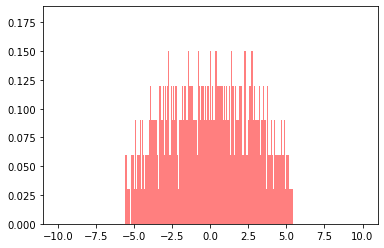

In [17]:
### Spectrum of adjacency matrix - plot

# Todo: Plot with the underlying graphs as well, unweighted. See if it's just scaling


Bin = np.linspace(-10,10,600)
# plt.hist(h_25, bins = Bin, density = True, alpha = .5, label = "$p=.25$", color="blue")
# plt.hist(h_50, bins = Bin, density = True, alpha = .5, label = "$p=.50$",color="green")
plt.hist(L, bins = Bin, density = True, alpha = .5, label = "$p=.75$",color="red")
plt.show()
# plt.hist(h_90, bins = Bin, density = True, alpha = .5, label = "$p=.90$",color="orange")

# plt.hist(h_90, bins = Bin, density = True, alpha = .5, label = "$p=.9$")
# plt.legend(loc='best')
# plt.ylabel("Density")
# plt.xlabel("Eigenvalues")
# plt.title("Distribution of $Spec(\Gamma(100,p))$ as $p$ changes")
# plt.savefig("Spec_dist_f_p.png")
# plt.clf()

# ### Spectrum of adjacency matrix - plot

# # Todo: Plot with the underlying graphs as well, unweighted. See if it's just scaling


# Bin = np.linspace(-300,300,600)
# plt.hist(h_u_25, bins = Bin, density = True, alpha = .5, label = "$p=.25$", color="blue")
# plt.hist(h_u_50, bins = Bin, density = True, alpha = .5, label = "$p=.50$",color="green")
# plt.hist(h_u_75, bins = Bin, density = True, alpha = .5, label = "$p=.75$",color="red")
# plt.hist(h_u_90, bins = Bin, density = True, alpha = .5, label = "$p=.90$",color="orange")

# # plt.hist(h_90, bins = Bin, density = True, alpha = .5, label = "$p=.9$")
# plt.legend(loc='best')
# plt.ylabel("Density")
# plt.xlabel("Eigenvalues")
# plt.title("Distribution of $Spec(\Gamma(100,p))$ as $p$ changes")
# plt.savefig("Spec_dist_f_p_complete.png")
# plt.clf()
# ### Spectrum of adjacency matrix - plot

# # Todo: Plot with the underlying graphs as well, unweighted. See if it's just scaling


# Bin = np.linspace(-300,300,600)
# plt.hist(hc_25, bins = Bin, density = True, alpha = .5, label = "$p=.25$", color="blue")
# plt.hist(hc_50, bins = Bin, density = True, alpha = .5, label = "$p=.50$",color="green")
# plt.hist(hc_75, bins = Bin, density = True, alpha = .5, label = "$p=.75$",color="red")
# plt.hist(hc_90, bins = Bin, density = True, alpha = .5, label = "$p=.90$",color="orange")

# # plt.hist(h_90, bins = Bin, density = True, alpha = .5, label = "$p=.9$")
# plt.legend(loc='best')
# plt.ylabel("Density")
# plt.xlabel("Eigenvalues")
# plt.title("Distribution of $Spec(\Gamma(100,p))$ as $p$ changes")
# plt.savefig("Spec_dist_f_p_after_completion.png")
# plt.clf()

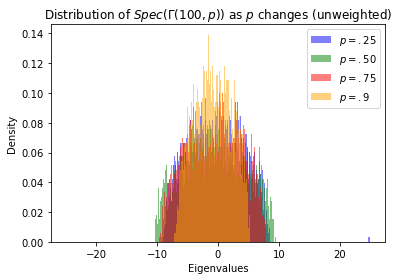

In [21]:
### Spectrum of adjacency matrix - plot

# Todo: Plot with the underlying graphs as well, unweighted. See if it's just scaling


Bin = np.linspace(-25,25,600)
plt.hist(h_u_25, bins = Bin, density = True, alpha = .5, label = "$p=.25$",color="blue")
plt.hist(h_u_50, bins = Bin, density = True, alpha = .5, label = "$p=.50$",color="green")
plt.hist(h_u_75, bins = Bin, density = True, alpha = .5, label = "$p=.75$",color="red")
plt.hist(h_u_90, bins = Bin, density = True, alpha = .5, label = "$p=.9$",color="orange")
plt.legend(loc='best')
plt.ylabel("Density")
plt.xlabel("Eigenvalues")
plt.title("Distribution of $Spec(\Gamma(100,p))$ as $p$ changes (unweighted)")
plt.savefig("Spec_dist_u_f_p.svg")

In [39]:
### Spectrum of adjacency matrix as a function of n

k=10 # number of iterations - to check distribution of eigenvalues. No need, the convergence
p=.5 # number of vertices
vert = [100,125,150]
# h_n_50 = list()
# h_n_75 = list()
# h_n_100= list()
# h_n_125 = list()
#     h_n_50+=list(eigh(random_geometric_weighted_graph(50,p).weighted_adjacency_matrix())[0])
#     h_n_75+=list(eigh(random_geometric_weighted_graph(75,p).weighted_adjacency_matrix())[0])
#     h_n_100+=list(eigh(random_geometric_weighted_graph(100,p).weighted_adjacency_matrix())[0])
#     h_n_125+=list(eigh(random_geometric_weighted_graph(125,p)\.weighted_adjacency_matrix())[0])

h_n_150 = list()
h_n2_150 = list()
h_n_350 = list()
h_n2_350 = list()
h_n_500 = list()
h_n2_500 = list()

for j in range(k):
    start_tot = timeit.timeit()
    if j % 5 == 0:
        print("###############")
        print("###############")
        print("###############")
        print(j)
    start = timeit.timeit()
    G500 = random_geometric_weighted_graph(50,p)
    A500 = G500.adjacency_matrix()
    W500 = G500.weighted_adjacency_matrix()
    end = timeit.timeit()
    print("finished 50")
    print("Time took:" + str(start - end))
    start = timeit.timeit()
    G150 = random_geometric_weighted_graph(150,p)
    A150=G150.adjacency_matrix()
    W150=G150.weighted_adjacency_matrix()
    end = timeit.timeit()
    print("finished 150")
    print("Time took:" + str(start - end))


    # G350 = random_geometric_weighted_graph(350,p)
    # print("finished generating graphs")

    # A350 = (1/np.sqrt(350))*G350.adjacency_matrix()

    # print("finished adjacency")    

    # W350 = G350.weighted_adjacency_matrix()

    # print("finished weighted adjacency")

    h_n_150+=list(eigh(W150)[0])
    h_n2_150+=list(eigh(A150)[0])
    print("finished 150")
    # h_n_350+=list(eigh(W350)[0])
    # h_n2_350+=list(eigh(A350)[0])
    print("finished 350")
    h_n_500+=list(eigh(W500)[0])
    h_n2_500+=list(eigh(A500)[0])
    
    end_tot = timeit.timeit()
    print(start_tot-end_tot)



###############
###############
###############
0
finished 50
Time took:0.004837084000428149
finished 150
Time took:-5.840001904289238e-07
finished 150
finished 350
0.006274082999880193
finished 50
Time took:2.1042000298621133e-05
finished 150
Time took:-1.6375000086554792e-05
finished 150
finished 350
2.1707999621867202e-05
finished 50
Time took:6.604200007132022e-05
finished 150
Time took:7.354199988185428e-05
finished 150
finished 350
4.799999987881165e-05
finished 50
Time took:-0.00010466700041433796
finished 150
Time took:1.7917000150191598e-05
finished 150
finished 350
-7.658300091861747e-05
finished 50
Time took:-0.00010320799992769025
finished 150
Time took:-0.00032804300008137943
finished 150
finished 350
-0.00014837499929853948
###############
###############
###############
5
finished 50
Time took:-0.00022312399960355833
finished 150
Time took:0.00010270900111208903
finished 150
finished 350
9.279200003220467e-05
finished 50
Time took:9.629200030758511e-05
finished 150
Time 

Text(0.5, 1.0, 'Distribution of $Spec(\\Gamma(n,.5))$ as $n$ changes')

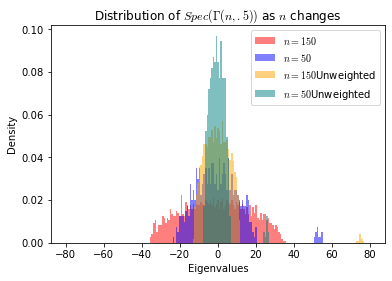

In [66]:
### Spectrum of adjacency matrix - plot

R = 80
Bin = np.linspace(-R,R,200)

# plt.hist(h_n_50, bins = Bin, density = True, alpha = .5, label = "$n=50$")
# plt.hist(h_n_75, bins = Bin, density = True, alpha = .5, label = "$n=75$")
# plt.hist(h_n_100, bins = Bin, density = True, alpha = .5, label = "$n=100$")
# plt.hist(h_n_125, bins = Bin, density = True, alpha = .5, label = "$n=125$")
plt.hist(h_n_150, bins = Bin, density = True, alpha = .5, label = "$n=150$", color = "red")
plt.hist(h_n_500, bins = Bin, density = True, alpha = .5, label = "$n=50$",color = "blue")
plt.hist(h_n2_150, bins = Bin, density = True, alpha = .5, label = "$n=150$" + "Unweighted", color = "orange")
plt.hist(h_n2_500, bins = Bin, density = True, alpha = .5, label = "$n=50$"+"Unweighted", color = "teal")
# plt.hist(h_200, bins = Bin, density = True, alpha = .5, label = "$n=200$")
plt.legend(loc='best')
plt.ylabel("Density")
plt.xlabel("Eigenvalues")
plt.title("Distribution of $Spec(\Gamma(n,.5))$ as $n$ changes")
# plt.savefig("Spec_dist_f_n.svg")

Text(0.5, 1.0, 'Distribution of $Spec(\\Gamma(n,.5))$ as $n$ changes (unweighted)')

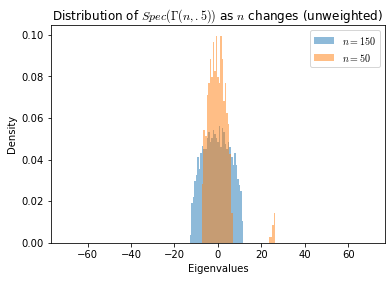

In [56]:
### Spectrum of adjacency matrix - plot


Bin = np.linspace(-R,R,200)

# plt.hist(h_n_50, bins = Bin, density = True, alpha = .5, label = "$n=50$")
# plt.hist(h_n_75, bins = Bin, density = True, alpha = .5, label = "$n=75$")
# plt.hist(h_n_100, bins = Bin, density = True, alpha = .5, label = "$n=100$")
# plt.hist(h_n_125, bins = Bin, density = True, alpha = .5, label = "$n=125$")
plt.hist(h_n2_150, bins = Bin, density = True, alpha = .5, label = "$n=150$")
plt.hist(h_n2_500, bins = Bin, density = True, alpha = .5, label = "$n=50$")
# plt.hist(h_200, bins = Bin, density = True, alpha = .5, label = "$n=200$")
plt.legend(loc='best')
plt.ylabel("Density")
plt.xlabel("Eigenvalues")
plt.title("Distribution of $Spec(\Gamma(n,.5))$ as $n$ changes (unweighted)")
# plt.savefig("Spec_dist_f_n.svg")